In [2]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../../temporal_context/config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries


In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    folder_name: str = "fewer_occlusion" #"talia_20each_tizi"
cfg = Cfg()

In [4]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [188]:
ba_raster = TimeSeries(raster.get_array()[:15, :, :], fs=cfg.new_fs)

In [6]:
from image_processing.computational_models import map_image_order_from_ann_to_monkey
from torchvision.datasets import ImageFolder
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; cfg.layer_name = 'blocks.16.mlp.fc2'
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)
feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]
features = features[:, idx_ord]

In [7]:
from sklearn.linear_model import LinearRegression, RidgeCV, MultiTaskLassoCV, MultiTaskElasticNetCV
from sklearn.model_selection import KFold, LeaveOneOut
from useful_stuff.general_utils.regression import IdentitySplit

def choose_regression_type(regression_type, alphas=np.logspace(-6, 3, 10), l1_ratio=[0.1, 0.5, 0.9], **kwargs):
    if regression_type == 'lr': 
        regression_obj = LinearRegression()
    elif regression_type == 'ridge': 
        regression_obj = RidgeCV(alphas=alphas)
    elif regression_type == 'lasso': 
        regression_obj = MultiTaskLassoCV(alphas=alphas, max_iter=10000)
    elif regression_type == 'en': 
        regression_obj = MultiTaskElasticNetCV(alphas=alphas, max_iter=10000, l1_ratio=l1_ratio)
    else:
        raise ValueError("regression_type must be 'lr', 'ridge', 'lasso', 'en'")
    return regression_obj
# EOF

def choose_CV_type(cv_type, n_splits=5, shuffle=True):
    if cv_type == 'same':
        CV = IdentitySplit(shuffle=shuffle)
    elif cv_type == 'loo': # leave one-out
        CV = LeaveOneOut()
    elif cv_type == 'kf': # leave one-out
        CV = KFold(n_splits=n_splits, shuffle=shuffle)
    else:
        raise ValueError("cv_type must be 'same', 'loo', 'kf'")
    # end if cv_type == 'same':
    return CV
# EOF

def evaluate_prediction_corr(Y_test, y_hat):
    if Y_test.shape[1]==1:
        raise ValueError("You can't run correlation with just 1 feature")
    # end if Y_test.shape[1]==1:
    corr_vals = np.array([np.corrcoef(y_hat[i, :], Y_test[i, :])[0, 1] for i in range(Y_test.shape[0])])
    if np.any(np.isnan(corr_vals)):
        Warning("We have NaNs in the correlation values")
    # end if np.any(np.isnan(corr_vals)):
    avg_corr = np.nanmean(corr_vals)
    return avg_corr
# EOF


In [288]:
from sklearn.metrics import r2_score
class linear_encoding:
    def __init__(self, regression_type: str, cv_type: str, alphas: np.ndarray=np.logspace(-6, 3, 10), score_type: str='r2', n_splits: int=5, shuffle: bool=True, **kwargs):
        self.regression_type = regression_type 
        self.alphas = alphas
        self.regression_obj = choose_regression_type(self.regression_type, alphas=self.alphas, **kwargs)
        self.cv_type = cv_type
        self.cv_obj = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        self.additional_args = kwargs
        self.score_type = score_type
    # EOF
    # --- GETTERS ---
    def get_regression_type(self):
        return self.regression_type
    # EOF
    def get_regression_obj(self):
        return self.regression_obj
    # EOF
    def get_alphas(self):
        return self.alphas
    # EOF
    def get_cv_type(self):
        return self.cv_type
    # EOF
    def get_cv_obj(self):
        return self.cv_obj
    # EOF
    def get_weights(self):
        return self.regression_obj.coef_
    # EOF
    def get_intercept(self):
        return self.regression_obj.intercept_
    # EOF
    def get_score_vals(self):
        return self.score_vals
    # EOF
    def get_score_type(self):
        return self.score_type
    # EOF
    # --- SETTERS ---
    def set_regression_type(self, regression_type: str, alphas=None, **kwargs):
        self.regression_type = regression_type
        if alphas is not None:
            self.alphas = alphas
        # end if alphas is not None:
        if kwargs is not None:
            self.additional_args = kwargs
        # end if kwargs is not None:
        self.regression_obj = choose_regression_type(self.regression_type, alphas=self.alphas, **self.additional_args)
    # EOF
    def set_regression_obj(self):
        raise AttributeError("Pass through set_regression_type to set a new regression object")
    # EOF
    def set_alphas(self):
        raise AttributeError("Pass through set_regression_type to set a new set of alphas")
    # EOF
    def set_cv_type(self, cv_type, n_splits=5, shuffle=True):
        self.cv_type = cv_type
        self.cv_obj = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
    # EOF
    def set_cv_obj(self):
        raise AttributeError("Pass through set_cv_type to set a new cv_obj")
    # EOF
    # --- OTHER METHODS ---
    def fit(self, X_train: np.ndarray, Y_train: np.ndarray, transpose=True):
        if transpose:
            X_train = np.ascontiguousarray(X_train.T)
            Y_train = np.ascontiguousarray(Y_train.T)
        # end if transpose:
        self.regression_obj.fit(X_train, Y_train)
        return self.get_weights(), self.get_intercept()
    # EOF
    def predict(self, X: np.ndarray, transpose=True, transpose_output=True):
        if transpose:
            X = np.ascontiguousarray(X.T)
        # end if transpose:
        y_hat = self.regression_obj.predict(X)
        if transpose_output:
            y_hat = np.ascontiguousarray(y_hat.T)
        # if transpose_output:
        return y_hat
    # EOF
    def score(self, X_test: np.ndarray, Y_test: np.ndarray, y_hat=None, transpose=True, transpose_prediction=True):
        if transpose:
            X_test = np.ascontiguousarray(X_test.T)
            Y_test = np.ascontiguousarray(Y_test.T)
        # end if transpose:
        if y_hat is None:
            y_hat = self.predict(X_test, transpose=False, transpose_output=False)
        else:
            if transpose_prediction:
                y_hat = np.ascontiguousarray(y_hat.T)
            # end if transpose_prediction:
        # end if y_hat is None:
        if self.score_type=='r2':
            score = r2_score(Y_test, y_hat, multioutput="raw_values")
        elif self.score_type=="corr": 
            score = evaluate_prediction_corr(Y_test, y_hat)
        # end if score_type=='r2':
        self.score_vals = score
        return score
    # EOF
    def crossvalidate(self, X, Y, transpose=True):
        if transpose:
            X = np.ascontiguousarray(X.T)
            Y = np.ascontiguousarray(Y.T)
        # end if transpose:
        counter = 0
        score = None
    
        for train_idx, test_idx in self.get_cv_obj().split(X):
            X_train, Y_train = X[train_idx, :], Y[train_idx, :]
            X_test, Y_test = X[test_idx, :], Y[test_idx, :]
            self.fit(X_train, Y_train, transpose=False)
            counter+=1
            if score is None:
                score = self.score(X_test, Y_test, transpose=False)
            else:
                score += self.score(X_test, Y_test, transpose=False)
            # end if score is None:
        # end for train_idx, test_idx in self.get_cv_obj().split(X):
        score = score/counter
        self.score_vals = score
        return score
    # EOC


In [88]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="r2")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_r2 = []
for i in range(10):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = None
    counter = 0
    # for train_idx, test_idx in model.get_cv_obj().split(X.T):
    #     X_train, Y_train = X[:, train_idx], Y[:, train_idx]
    #     X_test, Y_test = X[:, test_idx], Y[:, test_idx]
    #     model.fit(X_train, Y_train)
    #     y_pred = model.predict(X_test)
    #     counter+=1
    #     if score is None:
    #         score = model.score(X_test, Y_test)
    #     else:
    #         score += model.score(X_test, Y_test)
    score = model.crossvalidate(X, Y)
    time_score_r2.append(score)


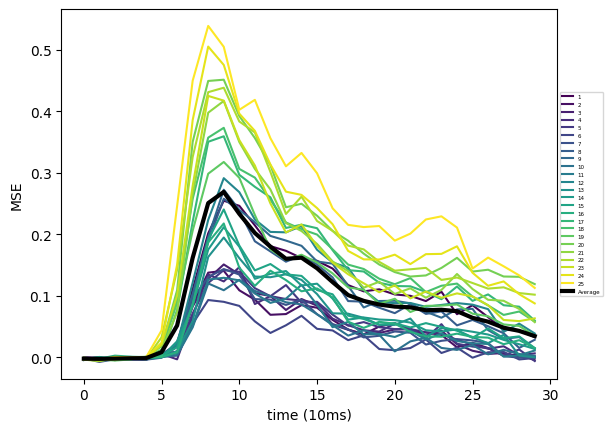

<Figure size 640x480 with 0 Axes>

In [29]:
if type(time_score_r2)== list: time_score_r2 = np.stack(time_score_r2, axis=-1)
for i, c in enumerate(colors):
    plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(time_score_r2, axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="corr")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_corr = []
for i in range(t_pts):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = model.crossvalidate(X, Y)
    time_score_corr.append(score)


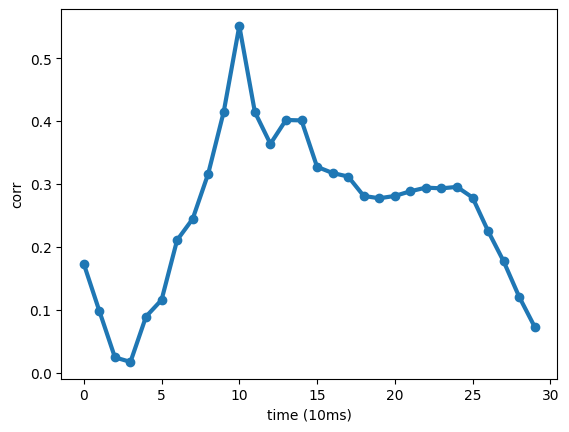

<Figure size 640x480 with 0 Axes>

In [34]:
if type(time_score_corr) == list: time_score_corr = np.stack(time_score_corr, axis=-1)
plt.plot(time_score_corr, "-o", linewidth=3)
# plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("corr")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [27]:
def static_lagged_linear_regression(x, y, regression_type='lr', alphas=np.logspace(-6, 3, 10), cv_type='same', n_splits=5, shuffle=True):
    lr_list = []
    x_shifted_tot = x.T
    for tau in range(y.shape[1]):
        y_shifted_tot = y[:,tau,:].T
        CV = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        curr_lr = []
        for train_idx, test_idx in CV.split(x_shifted_tot):
            train_x, train_y = x_shifted_tot[train_idx, :], y_shifted_tot[train_idx, :]
            test_x, test_y = x_shifted_tot[test_idx, :], y_shifted_tot[test_idx, :]
            regression_obj = choose_regression_type(regression_type=regression_type, alphas=alphas)
            regression_obj = regression_obj.fit(train_x, train_y)
            avg_corr = evaluate_prediction(test_x, test_y, regression_obj)
            curr_lr.append(avg_corr)
        # end for train_idx, test_idx in CV.split(x_shifted_tot):
        lr_list.append(np.nanmean(curr_lr))  #x_t_shifted_tot, y_t_shifted_tot))
    # end for L in range(-max_lag, max_lag):    
    return lr_list
# EOF


In [ ]:


class dyn_linear_encoding(linear_encoding):
    def __init__(self, regression_type, cv_type, max_lag: int, symmetric: bool=False, alphas = np.logspace(-6, 3, 10), score_type = 'r2', n_splits = 5, shuffle = True, **kwargs):
        super().__init__(regression_type, cv_type, alphas, score_type, n_splits, shuffle, **kwargs)
        self.max_lag = max_lag
        self.symmetric = symmetric
    # EOF
    # --- GETTERS ---
    def get_max_lag(self):
        return self.max_lag
    # EOF
    def get_symmetric(self):
        return self.symmetric
    # EOF
    def get_weights_dyn(self):
        return self.weights_dyn
    # EOF
    def get_intercepts_dyn(self):
        return self.intercepts_dyn
    # EOF
    # --- SETTERS ---
    def set_max_lag(self, max_lag: int):
        self.max_lag = max_lag
    # EOF
    def set_symmetric(self, symmetric: bool):
        self.symmetric = symmetric
    # EOF
    def set_weights_dyn(self, weights: TimeSeries):
        self.weights_dyn = weights
    # EOF
    def set_intercepts_dyn(self, intercepts: TimeSeries):
        self.intercepts_dyn = intercepts
    # EOF

    # --- OTHER METHODS ---
    # --- STATIC-DYNAMIC (= model is static, signal is dynamic)
    def fit_static_dyn(self, X_train: np.ndarray, Y_train: TimeSeries, transpose=True):
        if transpose:
            X_train = np.ascontiguousarray(X_train.T)
        # end if transpose:
        weights_dyn = []
        intercepts_dyn = []
        for y_t in Y_train:
            if transpose:
                y_t = np.ascontiguousarray(y_t.T)
            # end if transpose:
            w_t, w0_t = self.fit(X_train, y_t, transpose=False)
            weights_dyn.append(w_t)
            intercepts_dyn.append(w0_t)
        weights_dyn = TimeSeries(weights_dyn, Y_train.get_fs())
        intercepts_dyn = TimeSeries(intercepts_dyn, Y_train.get_fs())
        self.weights_dyn = weights_dyn
        self.intercepts_dyn = intercepts_dyn
        return weights_dyn, intercepts_dyn
    # EOF
    def predict_static_dyn(self, X: np.ndarray, transpose=True, transpose_output=True):
        y_hat_dyn = []
        if transpose:
            X = X.T
        # end if transpose
        for w, i in zip(self.get_weights_dyn(), self.get_intercepts_dyn()):
            # if len(w.shape) == 2: # transpose in case you had to predict multiple outputs
            w = w.T
            # end if len(w.shape) == 2:
            y_hat =  X @ w + i
            if transpose_output:
                y_hat = y_hat.T
            # end if transpose_output:
            y_hat_dyn.append(y_hat)
        # end for w, i in zip(self.get_weights_dyn(), self.get_weights_dyn()):
        y_hat_dyn = TimeSeries(y_hat_dyn, self.get_weights_dyn().get_fs())
        return y_hat_dyn
    # EOF
    def score_static_dyn(self, X_test: np.ndarray, Y_test: TimeSeries, y_hat=None, transpose=True, transpose_prediction=True):
        if transpose:
            X_test = np.ascontiguousarray(X_test.T)
            # Y_test = np.ascontiguousarray(Y_test.T)
        # end if transpose:
        if y_hat is None:
            y_hat = self.predict_static_dyn(X_test, transpose=False, transpose_output=False)
        else:
            if transpose_prediction:
                y_hat = TimeSeries([np.ascontiguousarray(y_t.T) for y_t in y_hat], y_hat.get_fs())
            # end if transpose_prediction:
        # end if y_hat is None:
        score_dyn = []
        for y_t, y_hat_t in zip(Y_test, y_hat):
            if self.score_type=='r2':
                score = r2_score(y_t, y_hat_t, multioutput="raw_values")
            elif self.score_type=="corr": 
                score = evaluate_prediction_corr(y_t, y_hat_t)
            # end if score_type=='r2':
            score_dyn.append(score)
        # end for y_t, y_hat_t in zip(Y_test, y_hat):
        time_score = np.stack(time_score, axis=-1) # time in the 0th or 1st axis depending on the evaluation used (corr has 1 feat, MSE has D)
        if len(time_score.shape)==1: # appends a dimension if the score is correlation
            time_score = time_score[np.newaxis, :]
        # end if len(time_score.shape)==1:
        self.score_vals_dyn = TimeSeries(score_dyn, Y_test.get_fs())
        return score_dyn
    # EOF
    def crossvalidate_static_dyn(self, X: np.ndarray, Y: TimeSeries, transpose=True):
        time_score = []
        for y_t in Y:
            score = self.crossvalidate(X, y_t, transpose=transpose)
            time_score.append(score)
        # end for y_t in Y:
        time_score = np.stack(time_score, axis=-1) # time in the 0th or 1st axis depending on the evaluation used (corr has 1 feat, MSE has D)
        if len(time_score.shape)==1: # appends a dimension if the score is correlation
            time_score = time_score[np.newaxis, :]
        # end if len(time_score.shape)==1:
        return TimeSeries(time_score, Y.get_fs())
    # EOF

    # --- TIME GENERAL (= shared weights for the same lag across datapoints)
    def fit_general_dyn(self, X_train: TimeSeries, Y_train: TimeSeries, transpose=True):
        weights_dyn = []
        intercepts_dyn = []
        lags_range = get_lags(self.max_lag, self.symmetric)
        for tau in lags_range:
            x_shifted, y_shifted = shift_concatenate_xy(X_train, Y_train, tau, transpose=transpose) 
            w_t, w0_t = self.fit(x_shifted, y_shifted, transpose=False)
            weights_dyn.append(w_t)
            intercepts_dyn.append(w0_t)
        # end for tau in lags_range:
        weights_dyn = TimeSeries(weights_dyn, Y_train.get_fs())
        intercepts_dyn = TimeSeries(intercepts_dyn, Y_train.get_fs())
        self.weights_dyn = weights_dyn
        self.intercepts_dyn = intercepts_dyn
        return weights_dyn, intercepts_dyn
    # EOF
    def predict_general_dyn(self, X_t: np.ndarray, transpose=True, transpose_output=True): # given a timepoint in the model, I want to predict the neural activity before and after it
        # don't accept X as a TimeSeries because the shift concatenate would yield a not so interpretable output otherwise
        return self.predict_static_dyn(X_t, transpose=transpose, transpose_output=transpose_output) # it is the same as the static version, only in this case the weights start from before the model at t
    # EOF
    def score_general_dyn(self, X_test: TimeSeries, Y_test: TimeSeries, y_hat=None, transpose_prediction=True):
        lags_range = get_lags(self.max_lag, self.symmetric)
        w = self.get_weights_dyn()       
        i = self.get_intercepts_dyn()       
        time_score = []
        for idx, tau in enumerate(lags_range):
            x_shifted, y_shifted = shift_concatenate_xy(X_test, Y_test, tau, transpose=True) # transpose=True because the TimeSeries will be DxN for sure
            w_t = w[idx]
            i_t = i[idx]
            if y_hat is None:
                w_t = w_t.T
                y_hat_t =  x_shifted @ w_t + i_t
            else:
                y_hat_t = y_hat[idx]
            # end if y_hat is None:
            if self.score_type=='r2':
                score = r2_score(y_shifted, y_hat_t, multioutput="raw_values")
            elif self.score_type=="corr": 
                score = evaluate_prediction_corr(y_shifted, y_hat_t)
            # end if score_type=='r2':
            time_score.append(score)
            # end for y_t, y_hat_t in zip(Y_test, y_hat):
        time_score = np.stack(time_score, axis=-1) # time in the 0th or 1st axis depending on the evaluation used (corr has 1 feat, MSE has D)
        if len(time_score.shape)==1: # appends a dimension if the score is correlation
            time_score = time_score[np.newaxis, :]
        # end if len(time_score.shape)==1:
        self.score_vals_dyn = TimeSeries(time_score, Y_test.get_fs())
        return self.score_vals_dyn
    # EOF
    def crossvalidate_general_dyn(self, X: TimeSeries, Y: TimeSeries):
        lags_range = get_lags(self.max_lag, self.symmetric)
        time_score = []
        for tau in lags_range:
            x_shifted, y_shifted = shift_concatenate_xy(X, Y, tau, transpose=True) # transpose=True because the TimeSeries will be DxN for sure
            score = self.crossvalidate(x_shifted, y_shifted, transpose=False)
            time_score.append(score)
        # end for y_t in Y:
        time_score = np.stack(time_score, axis=-1) # time in the 0th or 1st axis depending on the evaluation used (corr has 1 feat, MSE has D)
        if len(time_score.shape)==1: # appends a dimension if the score is correlation
            time_score = time_score[np.newaxis, :]
        # end if len(time_score.shape)==1:
        self.score_vals_dyn = TimeSeries(time_score, Y.get_fs())
        return self.score_vals_dyn
    # EOF

    # TODO --- TIME SPECIFIC (= each datapoint has its own weight - typically used if we short stimuli with a specific timecourse)

    # time-dependent
    # fit

    # predict

    # score

    # cross-validate


                

In [93]:
model = dyn_linear_encoding('ridge', 'kf', score_type="r2")
s = model.crossvalidate_static_dyn_linear_encoding(features, ba_raster) #TimeSeries(ba_raster[:10], ba_raster.get_fs()))

In [112]:
model.get_weights_dyn()[0].shape

(5, 1024)

In [195]:
model = dyn_linear_encoding('ridge', 'kf', score_type="r2", max_lag=None)
model.fit_static_dyn(features[:,:100], TimeSeries(ba_raster.get_array()[:,:30, :100], ba_raster.get_fs()))
p = model.predict_static_dyn(features[:,:20], transpose=True)
# fix transpose in predict
# do predict in general dyn

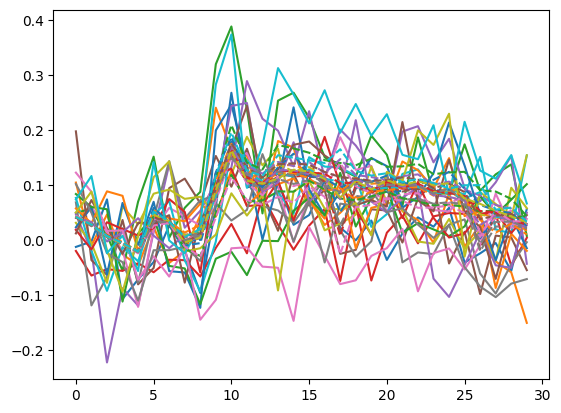

In [196]:
p_arr = np.stack(p.get_array(), axis=1)
plt.plot(np.mean(ba_raster.get_array()[:,:30,:20], axis=0));
plt.plot(np.mean(p_arr, axis=0), linestyle="--");

In [ ]:
model = dyn_linear_encoding('ridge', 'kf', 10, score_type="r2", symmetric=True)
model.fit_general_dyn(TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()))
p = model.predict_general_dyn(ba_raster.get_array()[:,15, :100])
s = model.score_general_dyn(TimeSeries(ba_raster.get_array()[:,:30, 4000:], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:30, 4000:], ba_raster.get_fs()))

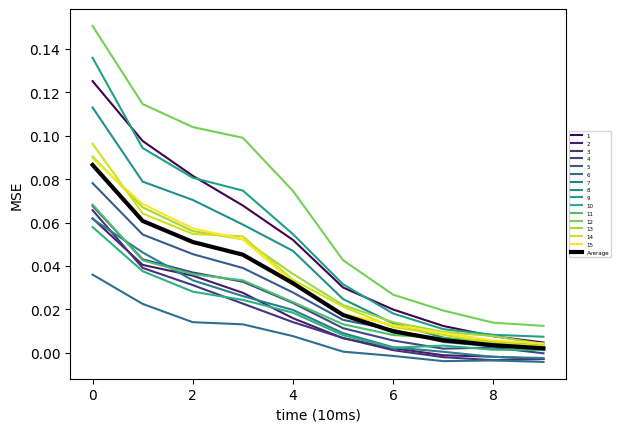

<Figure size 640x480 with 0 Axes>

In [279]:
cmap = plt.cm.viridis
t_pts = len(s)
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
for i, c in enumerate(colors):
    plt.plot(s.get_array().T[1:, i], color=c, label=f"{i+1}");
    # plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array()[:,1:], axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [296]:
model = dyn_linear_encoding('ridge', 'kf', 10, score_type="r2", symmetric=True)
# model.fit_general_dyn(TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()))
s = model.crossvalidate_general_dyn(TimeSeries(ba_raster.get_array()[:25,:20, :400], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:25,:20, :400], ba_raster.get_fs()))

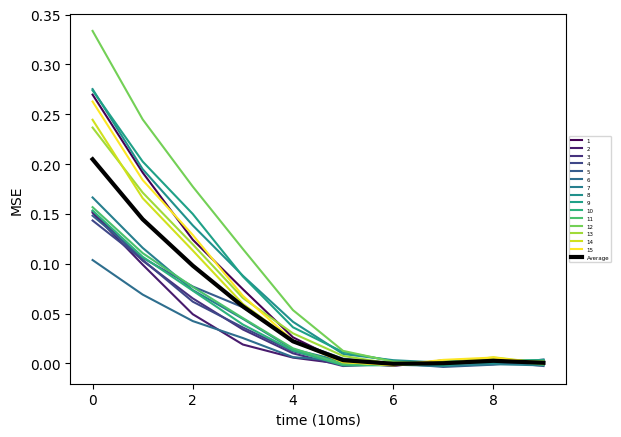

<Figure size 640x480 with 0 Axes>

In [ ]:
cmap = plt.cm.viridis
t_pts = len(s)
colors = cmap(np.linspace(0, 1, s.get_array().shape[0]))
for i, c in enumerate(colors):
    plt.plot(s.get_array().T[1:, i], color=c, label=f"{i+1}");
    # plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array()[:,1:], axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

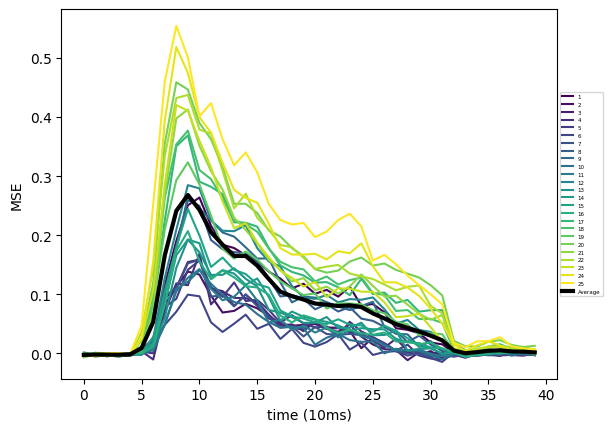

<Figure size 640x480 with 0 Axes>

In [84]:
if type(time_score_r2)== list: time_score_r2 = np.stack(time_score_r2, axis=-1)
for i, c in enumerate(colors):
    plt.plot(s.get_array()[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array(), axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [86]:
model = dyn_linear_encoding('ridge', 'kf', score_type="corr")
s = model.crossvalidate_static_dyn_linear_encoding(features, ba_raster) #TimeSeries(ba_raster[:10], ba_raster.get_fs()))

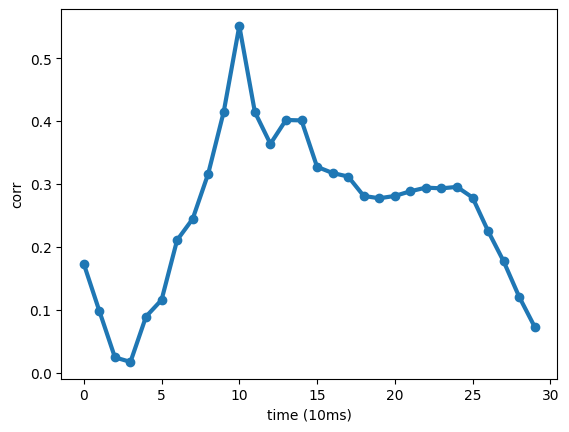

<Figure size 640x480 with 0 Axes>

In [ ]:
# if type(time_score_corr) == list: time_score_corr = np.stack(time_score_corr, axis=-1)
plt.plot(s.get_array(), "-o", linewidth=3)
# plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("corr")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [ ]:
from einops import rearrange # if I'll ever need to, in arrays with more than 2 dims (with reps), this would work fine
rearrange(np.random.randn(3,10, 4), 'D N ... -> N D ...').shape

(10, 3, 4)

In [44]:
import matplotlib.pyplot as plt
import numpy as np

model = dyn_linear_encoding('ridge', 'kf', score_type="corr")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_corr = []
for i in range(t_pts-15):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = None
    counter = 0
    score = model.crossvalidate(X, Y)
    time_score_corr.append(score)

# TODO 
- function to run (get weights, scores and crossvalidate) general dyn linear encoding
- function to run (get weights, scores and crossvalidate) time specific dyn linear encoding
- function to stack 4th dim of data when we have multiple reps (treat them as datapoints of a noisy measure)

In [ ]:
def lagged_linear_regression(x, y, regression_type='lr', alpha=0.0, cv_type='same', n_splits=5, shuffle=True, max_lag=20, symmetric=False):
    lr_list = []
    if symmetric:
        lags_range = range(max_lag+1)
    else:
        lags_range = range(-max_lag, max_lag+1)
    # end if symmetric:

    for tau in lags_range:
        x_shifted_tot, y_shifted_tot = shift_concatenate_xy(x, y, tau)
        CV = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        curr_lr = []
        for train_idx, test_idx in CV.split(x_shifted_tot):
            train_x, train_y = x_shifted_tot[train_idx, :], y_shifted_tot[train_idx, :]
            test_x, test_y = x_shifted_tot[test_idx, :], y_shifted_tot[test_idx, :]
            regression_obj = choose_regression_type(regression_type=regression_type, alpha=alpha)
            regression_obj = regression_obj.fit(train_x, train_y)
            #R2 = regression_obj.score(test_x, test_y) # later add correlation and see if add weights or something else
            avg_corr = evaluate_prediction(test_x, test_y, regression_obj)
            curr_lr.append(avg_corr)
        # end for train_idx, test_idx in CV.split(x_shifted_tot):
        lr_list.append(np.nanmean(curr_lr))  #x_t_shifted_tot, y_t_shifted_tot))
    # end for L in range(-max_lag, max_lag):    
    return lr_list
# EOF


"""
shift_concatenate_xy
Shifts temporally all the trials of two time-series x (model), y (neural signal) according to a lag tau. 
INPUT:
    - x: np.ndarray (features, timepoints, trials) -> regressor (i.e. model) time series 
    - y: np.ndarray (features, timepoints, trials) -> signal (i.e. neurons) time series
    - tau: int -> temporal lag
        tau < 0 we are using x future to predict current y
        tau = 0 we are using x present to predict current y
        tau > 0 we are using x past to predict current y
OUTPUT:
    - x_shifted: np.ndarray ((overlapping timepoints * trials), features) -> regressor (i.e. model) time series. 
                            overlapping timepoints = the timepoints that still have a correspondent in the other time series
                            the different trials are vectorized in the 0th dimension in the format regression_obj wants
    - y_shifted: np.ndarray ((overlapping timepoints * trials), features) -> signal (i.e. neurons) time series
"""
def shift_concatenate_xy(x, y, tau, transpose=True):
    x_shifted_tot = []
    y_shifted_tot = []
    
    for i_trial in range(x.get_array().shape[2]):
        curr_x = x.get_array()[:,:,i_trial]
        curr_y = y.get_array()[:,:,i_trial]
        x_shifted, y_shifted = shift_xy(curr_x, curr_y, tau)
        if transpose:
            x_shifted = np.ascontiguousarray(x_shifted.T)
            y_shifted = np.ascontiguousarray(y_shifted.T)
        # end if transpose:
        x_shifted_tot.append(x_shifted)
        y_shifted_tot.append(y_shifted)
    # end for i in range(data.shape[2]):
    axis = 0 if transpose else 1 # concatenate along the rows if transpose, otherwise the columns -> result: 1st case) NxD; 2nd case) DxN
    x_shifted_tot = np.concatenate(x_shifted_tot, axis=axis)
    y_shifted_tot = np.concatenate(y_shifted_tot, axis=axis)
    return x_shifted_tot, y_shifted_tot
# EOF


"""
shift_xy
Shifts temporally two time-series x (model), y (neural signal) according to a lag tau. 
INPUT:
    - x: np.ndarray (features, timepoints) -> regressor (i.e. model) time series 
    - y: np.ndarray (features, timepoints) -> signal (i.e. neurons) time series
    - tau: int -> temporal lag
        tau < 0 we are using x future to predict current y
        tau = 0 we are using x present to predict current y
        tau > 0 we are using x past to predict current y
OUTPUT:
    - x_shifted: np.ndarray (features, overlapping timepoints) -> regressor (i.e. model) time series. 
                            overlapping timepoints = the timepoints that still have a correspondent in the other time series
    - y_shifted: np.ndarray (features, overlapping timepoints) -> signal (i.e. neurons) time series
"""
def shift_xy(x, y, tau):
    if tau > 0:  # if positive lag
        x_shifted = x[:,:-tau] # mod is shifted towards the right (so present neural is being compared with past model)
        y_shifted = y[:,tau:]   
    elif tau == 0:  # Handle L=0 case explicitly
        x_shifted = x
        y_shifted = y
    else:  # tau < 0
        x_shifted = x[:,-tau:] # mod is shifted towards the left (so present neural is being compared with future model)
        y_shifted = y[:,:tau]
    # if tau > 0:  # if positive lag
    return x_shifted, y_shifted
#EOF



(1, 19, 4) (1, 19, 4)


ValueError: x and y can be no greater than 2D, but have shapes (4,) and (4, 19, 1)

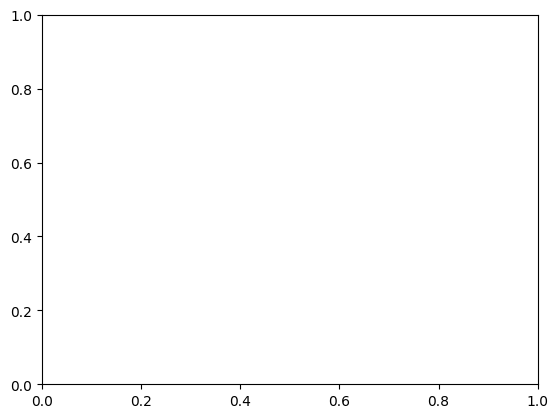

In [95]:
x = TimeSeries(np.random.randn(1, 20, 4), fs=10)
y = x
lag = -1
x_shifted, y_shifted = shift_xy(x, y, lag)
print(x_shifted.shape, y_shifted.shape)
plt.plot(x_shifted.T, marker="o", label="x")
plt.plot(y_shifted.T, marker="o", label="y")
plt.legend()
plt.title(f"lag = {lag}")

In [28]:
lr_list = static_lagged_linear_regression(feats, ba_raster.get_array(), regression_type='en', alphas=np.logspace(-6, 3, 10), cv_type='kf')

/Users/tizianocausin/Desktop/virtual_envs/temporal_context/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:673: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.714e+01, tolerance: 4.070e-02
  model = cd_fast.enet_coordinate_descent_multi_task(


KeyboardInterrupt: 

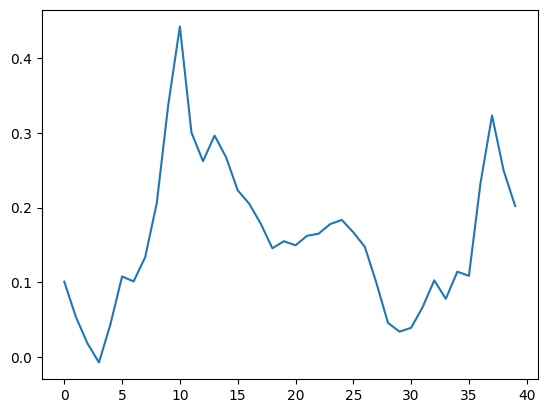

In [ ]:
plt.plot(lr_list)